# 01 · Data Exploration

1. Data inventory
2. Recipe metadata quality
3. Cooking time
4. Recipe complexity
5. Nutrition
6. Tags
7. Ingredients
8. Activity over time
9. Ratings
10. Long tail & sparsity
11. Train/validation/test splits
12. From stars to "enjoyed"
13. Global feature signal
14. Per-user taste
15. Evidence per user
16. Time
17. Recipe averages
18. Key takeaways for modeling

## 0 · Setup

In [1]:
from ast import literal_eval
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import yaml

# Resolve project root whether the notebook runs from notebooks/ or the repo root
ROOT = Path.cwd() if (Path.cwd() / "config.yaml").exists() else Path.cwd().parent
assert (ROOT / "config.yaml").exists(), "config.yaml not found - run from the repo or notebooks/"

CFG = yaml.safe_load((ROOT / "config.yaml").read_text())
DATA = ROOT / CFG["paths"]["data_dir"]

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Chart style: one validated palette, recessive chrome (colors pass CVD + contrast checks)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"   # categorical slots, fixed order
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"      # text
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlecolor": INK, "axes.titleweight": "bold", "axes.titlesize": 11.5,
    "axes.labelcolor": INK2, "axes.labelsize": 10,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "figure.dpi": 100,
})

def style(ax, xgrid=False):
    ax.grid(axis="y" if not xgrid else "x")
    return ax

In [2]:
# Download the dataset automatically if Data/ is empty (public dataset, no Kaggle account needed)
expected = ["RAW_recipes.csv", "RAW_interactions.csv", "interactions_train.csv",
            "interactions_validation.csv", "interactions_test.csv",
            "PP_recipes.csv", "PP_users.csv", "ingr_map.pkl"]
missing = [f for f in expected if not (DATA / f).exists()]
if missing:
    print("Missing files:", missing)
    import shutil
    import kagglehub  # pip install kagglehub
    src = Path(kagglehub.dataset_download("shuyangli94/food-com-recipes-and-user-interactions"))
    for f in expected:
        if not (DATA / f).exists():
            shutil.copy(src / f, DATA / f)
    print("Dataset downloaded into", DATA)
else:
    print("All 8 dataset files present in", DATA)

All 8 dataset files present in /Users/hannah/Bayesian_recipe_rec_project/Data


## 1 · Data inventory

Eight files. The `RAW_*` files are the human-readable source of truth; `interactions_*` are the
provided train/validation/test splits (with internal ids `u`, `i`); the `PP_*` files are tokenized
representations built for NLP models; `ingr_map.pkl` maps raw ingredient strings to canonical ids.

In [3]:
recipes = pd.read_csv(DATA / "RAW_recipes.csv")
interactions = pd.read_csv(DATA / "RAW_interactions.csv")
train = pd.read_csv(DATA / "interactions_train.csv")
validation = pd.read_csv(DATA / "interactions_validation.csv")
test = pd.read_csv(DATA / "interactions_test.csv")
pp_recipes = pd.read_csv(DATA / "PP_recipes.csv")
pp_users = pd.read_csv(DATA / "PP_users.csv")
ingr_map = pd.read_pickle(DATA / "ingr_map.pkl")

inventory = pd.DataFrame(
    [(n, d.shape[0], d.shape[1], d.memory_usage(deep=True).sum() / 1e6, ", ".join(d.columns[:8]))
     for n, d in [("RAW_recipes", recipes), ("RAW_interactions", interactions),
                  ("interactions_train", train), ("interactions_validation", validation),
                  ("interactions_test", test), ("PP_recipes", pp_recipes),
                  ("PP_users", pp_users), ("ingr_map", ingr_map)]],
    columns=["file", "rows", "cols", "memory_mb", "columns"],
)
inventory.style.format({"rows": "{:,}", "memory_mb": "{:,.0f}"}).hide(axis="index")

file,rows,cols,memory_mb,columns
RAW_recipes,"231,637",12,375,"name, id, minutes, contributor_id, submitted, tags, nutrition, n_steps"
RAW_interactions,"1,132,367",5,467,"user_id, recipe_id, date, rating, review"
interactions_train,"698,901",6,69,"user_id, recipe_id, date, rating, u, i"
interactions_validation,"7,023",6,1,"user_id, recipe_id, date, rating, u, i"
interactions_test,"12,455",6,1,"user_id, recipe_id, date, rating, u, i"
PP_recipes,"178,265",8,247,"id, i, name_tokens, ingredient_tokens, steps_tokens, techniques, calorie_level, ingredient_ids"
PP_users,"25,076",6,17,"u, techniques, items, n_items, ratings, n_ratings"
ingr_map,"11,659",7,3,"raw_ingr, raw_words, processed, len_proc, replaced, count, id"


In [4]:
recipes[["name", "id", "minutes", "submitted", "n_steps", "n_ingredients", "tags", "nutrition"]].head(3)

,name,id,minutes,submitted,n_steps,n_ingredients,tags,nutrition
0,arriba baked winter squash mexican style,137739,55,2005-09-16,11,7,"['60-minutes-or-less', 'time-to-make', 'course', 'main-ingredient', 'cuisine', 'prepar...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]"
1,a bit different breakfast pizza,31490,30,2002-06-17,9,6,"['30-minutes-or-less', 'time-to-make', 'course', 'main-ingredient', 'cuisine', 'prepar...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]"
2,all in the kitchen chili,112140,130,2005-02-25,6,13,"['time-to-make', 'course', 'preparation', 'main-dish', 'chili', 'crock-pot-slow-cooker...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]"


In [5]:
interactions.head(3)

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for 15 minutes.Added a shake of cayenne and...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall evening. Should have doubled it ;)<br/>..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not quite a whole package (10oz) of white c...


## 2 · Recipe metadata quality

`tags`, `ingredients`, `steps`, and `nutrition` are stored as *stringified Python lists* — they must be
parsed before use. `nutrition` is a fixed-length list:
`[calories, total fat %DV, sugar %DV, sodium %DV, protein %DV, saturated fat %DV, carbs %DV]`.

In [6]:
missing = pd.DataFrame({
    "missing": recipes.isna().sum(),
    "pct": 100 * recipes.isna().mean(),
})
display(missing[missing.missing > 0].style.format({"missing": "{:,}", "pct": "{:.2f}%"}))

print(f"duplicate recipe ids:   {recipes.id.duplicated().sum()}")
print(f"duplicate recipe names: {recipes.name.duplicated().sum():,}  "
      "(same dish contributed by different users - ids stay unique)")
print(f"duplicate (user, recipe) pairs in interactions: "
      f"{interactions.duplicated(['user_id', 'recipe_id']).sum():,}")

,missing,pct
name,1,0.00%
description,"4,979",2.15%


duplicate recipe ids:   0
duplicate recipe names: 1,451  (same dish contributed by different users - ids stay unique)
duplicate (user, recipe) pairs in interactions: 0


In [7]:
# Parse nutrition (fast vectorized split) and tags/ingredients (literal_eval - the slow cell, ~1 min)
NUTR_COLS = ["calories", "total_fat_pdv", "sugar_pdv", "sodium_pdv",
             "protein_pdv", "sat_fat_pdv", "carbs_pdv"]
recipes[NUTR_COLS] = (
    recipes["nutrition"].str.strip("[]").str.split(",", expand=True).astype(float)
)
recipes["tags_list"] = recipes["tags"].map(literal_eval)
recipes["ingredients_list"] = recipes["ingredients"].map(literal_eval)
recipes["n_tags"] = recipes["tags_list"].str.len()
recipes["submitted"] = pd.to_datetime(recipes["submitted"])
interactions["date"] = pd.to_datetime(interactions["date"])
print("parsed:", recipes.shape)

parsed: (231637, 22)


## 3 · Cooking time — extreme outliers

`minutes` is self-reported and unvalidated. The maximum is **2,147,483,647 minutes** — exactly the
32-bit integer limit, i.e. a deliberate joke entry (that's ~4,000 years). Several other recipes are
"aged" for weeks or months (preserves, liqueurs), and ~1K recipes claim 0 minutes.

In [8]:
q = recipes.minutes.quantile([0.01, 0.25, 0.50, 0.75, 0.90, 0.99, 0.999, 1.0]).rename("minutes")
display(q.to_frame().T.style.format("{:,.0f}"))

print(f"minutes == 0:        {(recipes.minutes == 0).sum():,} recipes")
print(f"minutes > 1440 (24h): {(recipes.minutes > 1440).sum():,} recipes "
      f"({100 * (recipes.minutes > 1440).mean():.2f}%)")

cols = ["name", "minutes", "n_steps", "n_ingredients"]
recipes.nlargest(10, "minutes")[cols].assign(days=lambda d: d.minutes / 1440)

,0.010000,0.250000,0.500000,0.750000,0.900000,0.990000,0.999000,1.000000
minutes,2,20,40,65,135,904,"10,095","2,147,483,647"


minutes == 0:        1,094 recipes
minutes > 1440 (24h): 2,000 recipes (0.86%)


,name,minutes,n_steps,n_ingredients,days
144074,no bake granola balls,2147483647,9,8,"1,491,308.09"
109624,how to preserve a husband,1051200,9,2,730.00
106563,homemade fruit liquers,288000,12,3,200.00
38116,celtic druid s honey mead meade metheglin,259260,18,7,180.04
106963,homemade vanilla,259205,9,2,180.00
155044,peach brandy,216015,9,4,150.01
5497,angelica liqueur,201610,7,7,140.01
177906,rumtopf,187200,16,8,130.00
170999,raspberry liqueur,172810,7,3,120.01
53721,cinnamon extract,172800,5,2,120.00


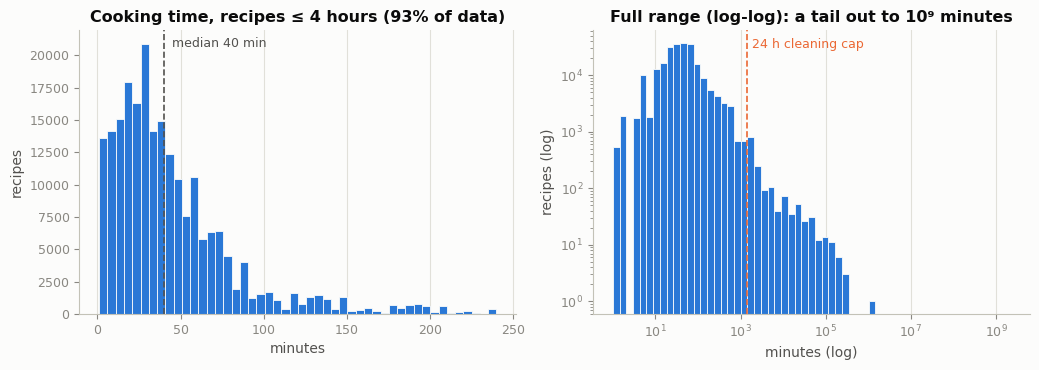

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))

ax = style(axes[0])
sub = recipes.loc[recipes.minutes.between(1, 240), "minutes"]
ax.hist(sub, bins=48, color=BLUE, edgecolor=SURFACE, linewidth=0.6)
med = recipes.minutes.median()
ax.axvline(med, color=INK2, linewidth=1.2, linestyle="--")
ax.text(med + 5, ax.get_ylim()[1] * 0.94, f"median {med:.0f} min", color=INK2, fontsize=9)
ax.set_title("Cooking time, recipes ≤ 4 hours (93% of data)")
ax.set_xlabel("minutes"); ax.set_ylabel("recipes")

ax = style(axes[1])
pos = recipes.loc[recipes.minutes > 0, "minutes"]
ax.hist(pos, bins=np.logspace(0, np.log10(pos.max()), 60), color=BLUE,
        edgecolor=SURFACE, linewidth=0.6)
ax.set_xscale("log"); ax.set_yscale("log")
ax.axvline(1440, color=ORANGE, linewidth=1.2, linestyle="--")
ax.text(1900, 3e4, "24 h cleaning cap", color=ORANGE, fontsize=9)
ax.set_title("Full range (log-log): a tail out to 10⁹ minutes")
ax.set_xlabel("minutes (log)"); ax.set_ylabel("recipes (log)")

fig.tight_layout(); plt.show()

**Cleaning rule.** Cap `minutes` at `config.yaml → data.max_minutes_after_cleaning = 1440` (drops or
winsorizes ~2K recipes, 0.9%) and treat `minutes == 0` as missing. Median cooking time is ~40 minutes;
after capping, the distribution is well-behaved and usable as a model feature (e.g. binned quick / normal / long).

## 4 · Recipe complexity — steps and ingredients

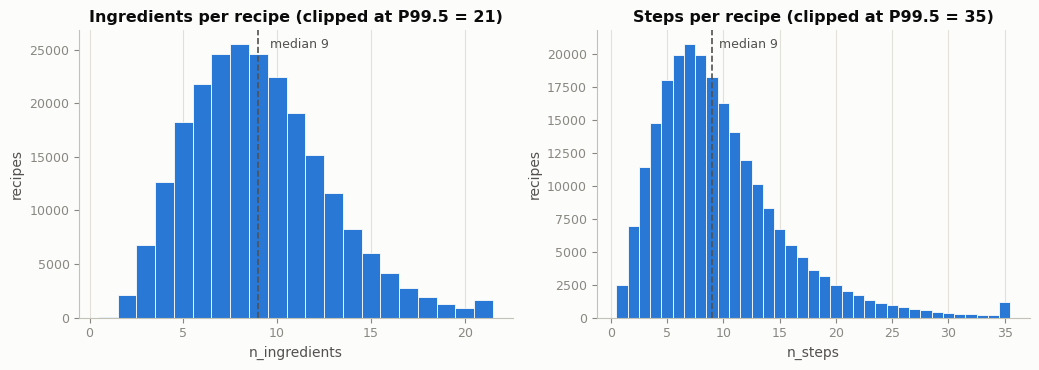

,n_ingredients,n_steps,n_tags
mean,9.05,9.77,17.88
50%,9.00,9.00,17.00
min,1.00,0.00,1.00
max,43.00,145.00,73.00


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))

for ax, col, title in [(axes[0], "n_ingredients", "Ingredients per recipe"),
                       (axes[1], "n_steps", "Steps per recipe")]:
    style(ax)
    vmax = int(recipes[col].quantile(0.995))
    ax.hist(recipes[col].clip(upper=vmax), bins=np.arange(0.5, vmax + 1.5), color=BLUE,
            edgecolor=SURFACE, linewidth=0.6)
    med = recipes[col].median()
    ax.axvline(med, color=INK2, linewidth=1.2, linestyle="--")
    ax.text(med + 0.6, ax.get_ylim()[1] * 0.94, f"median {med:.0f}", color=INK2, fontsize=9)
    ax.set_title(f"{title} (clipped at P99.5 = {vmax})")
    ax.set_xlabel(col); ax.set_ylabel("recipes")

fig.tight_layout(); plt.show()

recipes[["n_ingredients", "n_steps", "n_tags"]].describe().loc[["mean", "50%", "min", "max"]]

## 5 · Nutrition

Calories per serving also carry joke/bulk outliers (up to ~430K calories). Percent-daily-value
columns have similar tails. As with `minutes`, cap at a high percentile before using as features.

In [11]:
display(recipes[NUTR_COLS].quantile([0.25, 0.50, 0.75, 0.99, 1.0]).style.format("{:,.0f}"))
print(f"recipes with > 10,000 calories/serving: {(recipes.calories > 10_000).sum():,}")

,calories,total_fat_pdv,sugar_pdv,sodium_pdv,protein_pdv,sat_fat_pdv,carbs_pdv
0.250000,174,8,9,5,7,7,4
0.500000,313,20,25,14,18,23,9
0.750000,520,41,68,33,51,52,16
0.990000,"3,517",302,"1,142",219,188,404,154
1.000000,"434,360","17,183","362,729","29,338","6,552","10,395","36,098"


recipes with > 10,000 calories/serving: 125


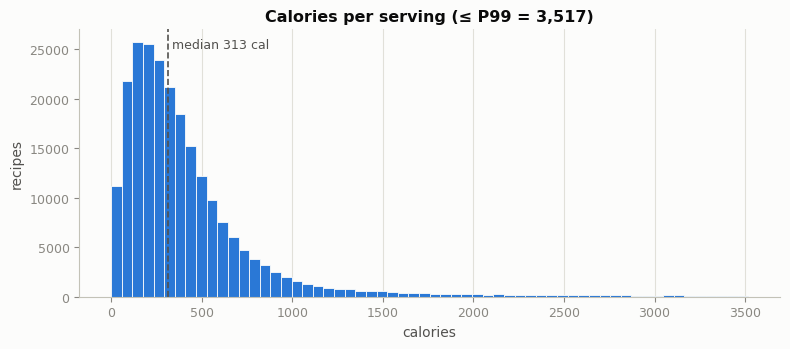

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.6))
style(ax)
p99 = recipes.calories.quantile(0.99)
ax.hist(recipes.loc[recipes.calories <= p99, "calories"], bins=60, color=BLUE,
        edgecolor=SURFACE, linewidth=0.6)
med = recipes.calories.median()
ax.axvline(med, color=INK2, linewidth=1.2, linestyle="--")
ax.text(med + 25, ax.get_ylim()[1] * 0.93, f"median {med:.0f} cal", color=INK2, fontsize=9)
ax.set_title(f"Calories per serving (≤ P99 = {p99:,.0f})")
ax.set_xlabel("calories"); ax.set_ylabel("recipes")
fig.tight_layout(); plt.show()

## 6 · Tags — the feature source for the Bayesian layer

Every recipe carries a rich tag list (median ~17 tags). The most frequent tags are structural
(`preparation`, `time-to-make`, `course`), but the mid-frequency band contains exactly what the
Beta–Binomial preference model needs: **cuisine, dietary, and dish-type categories**.

unique tags: 552   |   median tags per recipe: 17


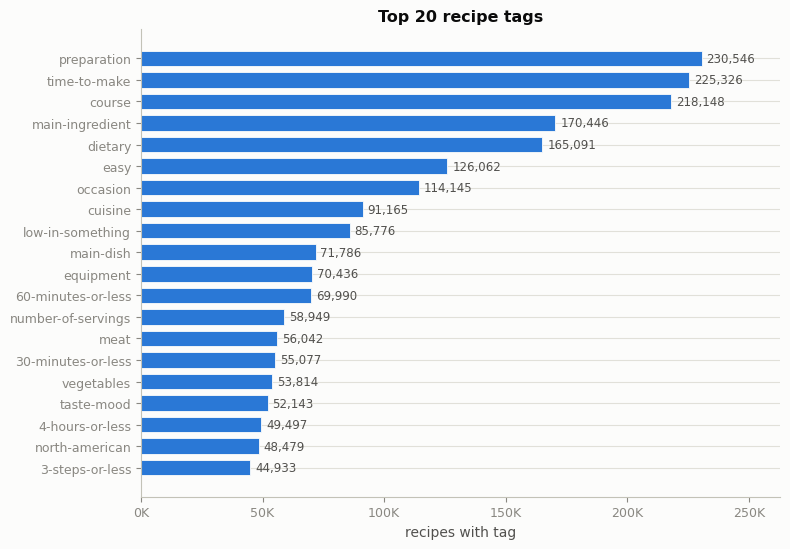

In [13]:
tag_counts = Counter(t for lst in recipes.tags_list for t in lst)
print(f"unique tags: {len(tag_counts):,}   |   median tags per recipe: {recipes.n_tags.median():.0f}")

top = pd.Series(dict(tag_counts.most_common(20))).sort_values()
fig, ax = plt.subplots(figsize=(8, 5.6))
style(ax, xgrid=True)
ax.barh(top.index, top.values, color=BLUE, edgecolor=SURFACE, linewidth=0.6, height=0.72)
for y, v in enumerate(top.values):
    ax.text(v + 2_000, y, f"{v:,}", va="center", color=INK2, fontsize=8.5)
ax.set_xlim(0, top.max() * 1.14)
ax.set_title("Top 20 recipe tags")
ax.set_xlabel("recipes with tag")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v / 1000:.0f}K"))
fig.tight_layout(); plt.show()

In [14]:
# Candidate feature tags for the Bayesian preference model (coverage in recipes)
candidates = {
    "cuisine":  ["italian", "mexican", "asian", "american", "french", "greek", "indian",
                 "chinese", "thai", "middle-eastern"],
    "dietary":  ["vegetarian", "vegan", "gluten-free", "low-carb", "low-fat", "low-sodium",
                 "low-cholesterol", "healthy"],
    "dish":     ["desserts", "main-dish", "side-dishes", "salads", "soups-stews",
                 "breakfast", "appetizers", "breads"],
    "time":     ["15-minutes-or-less", "30-minutes-or-less", "60-minutes-or-less",
                 "4-hours-or-less"],
}
rows = [(fam, tag, tag_counts.get(tag, 0), 100 * tag_counts.get(tag, 0) / len(recipes))
        for fam, tags in candidates.items() for tag in tags]
feat = pd.DataFrame(rows, columns=["family", "tag", "recipes", "coverage_pct"])
feat = feat[feat.recipes > 0].sort_values(["family", "recipes"], ascending=[True, False])
feat.style.format({"recipes": "{:,}", "coverage_pct": "{:.1f}%"}).hide(axis="index")

family,tag,recipes,coverage_pct
cuisine,american,"31,179",13.5%
cuisine,asian,"13,485",5.8%
cuisine,italian,"7,410",3.2%
cuisine,mexican,"6,694",2.9%
cuisine,indian,"2,708",1.2%
cuisine,greek,"2,391",1.0%
cuisine,french,"2,268",1.0%
cuisine,middle-eastern,"2,067",0.9%
cuisine,chinese,"2,008",0.9%
cuisine,thai,"1,208",0.5%


Coverage is high enough for per-user Beta–Binomial updating on these tag families: even the rarer
cuisine tags appear in thousands of recipes, and dietary/dish/time tags cover 10–50% of the catalog.

### Do the candidate tags overlap?

One caution before treating every tag as its own preference: several tags travel together.
If a user's "healthy" posterior looks good, their "low-fat" posterior will usually look good
*from the same recipes* — that is shared evidence, not independent confirmation.

most-overlapping candidate tag pairs (Jaccard = recipes with both / recipes with either):
          tag A           tag B  jaccard
low-cholesterol         healthy     0.59
        low-fat         healthy     0.55
        low-fat low-cholesterol     0.46
     low-sodium low-cholesterol     0.34
     low-sodium         healthy     0.32
     vegetarian           vegan     0.28
        low-fat      low-sodium     0.26
       low-carb      low-sodium     0.24


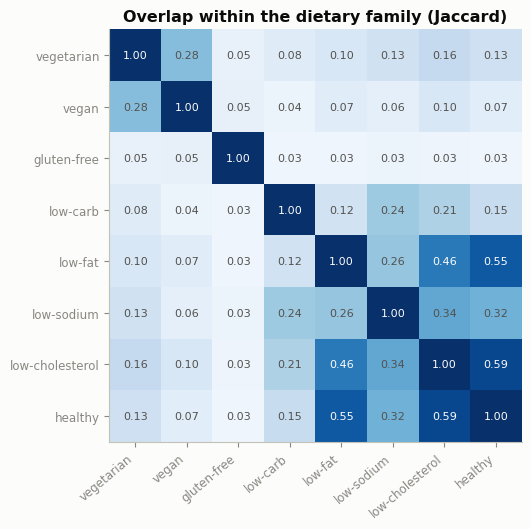

In [15]:
# Boolean recipe x tag matrix for the candidate tags (reused by sections 12-16)
CAND_TAGS = [t for fam_tags in candidates.values() for t in fam_tags]
tag_sets = recipes["tags_list"].map(set)
tag_flags = pd.DataFrame({t: tag_sets.map(lambda s, t=t: t in s) for t in CAND_TAGS})

M = tag_flags.to_numpy(np.float32)
inter = M.T @ M
sizes = np.diag(inter)
jac = inter / (sizes[:, None] + sizes[None, :] - inter)

iu = np.triu_indices(len(CAND_TAGS), 1)
pairs = pd.DataFrame({"tag A": np.array(CAND_TAGS)[iu[0]], "tag B": np.array(CAND_TAGS)[iu[1]],
                      "jaccard": jac[iu]}).nlargest(8, "jaccard")
print("most-overlapping candidate tag pairs (Jaccard = recipes with both / recipes with either):")
print(pairs.round(2).to_string(index=False))

diet = candidates["dietary"]
di = [CAND_TAGS.index(t) for t in diet]
fig, ax = plt.subplots(figsize=(6.6, 5.4))
ax.imshow(jac[np.ix_(di, di)], cmap="Blues", vmin=0, vmax=0.65)
ax.set_xticks(range(len(diet)), diet, rotation=40, ha="right", fontsize=8.5)
ax.set_yticks(range(len(diet)), diet, fontsize=8.5)
for a in range(len(diet)):
    for b in range(len(diet)):
        v = jac[di[a], di[b]]
        ax.text(b, a, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color=SURFACE if v > 0.4 else INK2)
ax.set_title("Overlap within the dietary family (Jaccard)")
ax.grid(False)
fig.tight_layout(); plt.show()

**The dietary family is really about two concepts.** `healthy`, `low-fat`, `low-cholesterol`,
and `low-sodium` overlap heavily (Jaccard 0.32-0.59) — closer to one "health-conscious" signal than
four separate tastes — and `vegetarian`/`vegan` form a second cluster (0.28). Across families the
strongest link is `main-dish` ↔ `60-minutes-or-less` (0.22). For the Bayesian layer: either collapse
each cluster into one feature, or remember that these posteriors share evidence and will move together.

## 7 · Ingredients

Raw ingredient strings are noisy (11.7K raw variants). `ingr_map.pkl` maps them to canonical ids —
use the `replaced` / `id` columns when building ingredient features.

unique raw ingredient strings in recipes: 14,942
ingr_map: 11,659 raw variants -> 8,023 canonical ingredients


,raw_ingr,replaced,id
0,"medium heads bibb or red leaf lettuce, washed, dried* and torn into pieces",lettuce,4308
1,mixed baby lettuces and spring greens,lettuce,4308
2,romaine lettuce leaf,lettuce,4308
3,iceberg lettuce leaf,lettuce,4308


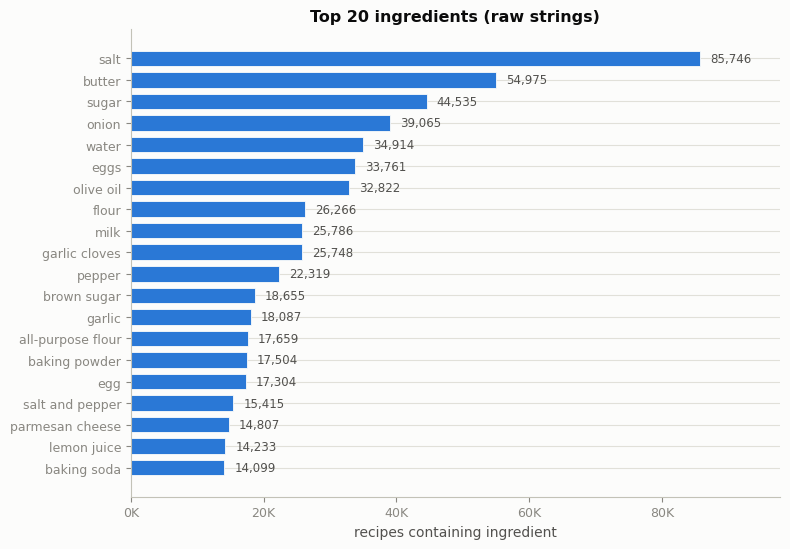

In [16]:
ingr_counts = Counter(i for lst in recipes.ingredients_list for i in lst)
print(f"unique raw ingredient strings in recipes: {len(ingr_counts):,}")
print(f"ingr_map: {len(ingr_map):,} raw variants -> {ingr_map['id'].nunique():,} canonical ingredients")
display(ingr_map[["raw_ingr", "replaced", "id"]].head(4))

top = pd.Series(dict(ingr_counts.most_common(20))).sort_values()
fig, ax = plt.subplots(figsize=(8, 5.6))
style(ax, xgrid=True)
ax.barh(top.index, top.values, color=BLUE, edgecolor=SURFACE, linewidth=0.6, height=0.72)
for y, v in enumerate(top.values):
    ax.text(v + 1_500, y, f"{v:,}", va="center", color=INK2, fontsize=8.5)
ax.set_xlim(0, top.max() * 1.14)
ax.set_title("Top 20 ingredients (raw strings)")
ax.set_xlabel("recipes containing ingredient")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v / 1000:.0f}K"))
fig.tight_layout(); plt.show()

### How many ingredients would features need?

Raw ingredient strings are noisy, but the canonical map makes the space compact. How many canonical
ingredients does it take to cover most of the catalog?

2,096,582 ingredient mentions | 0.2% unmapped | 8,023 distinct canonical ingredients


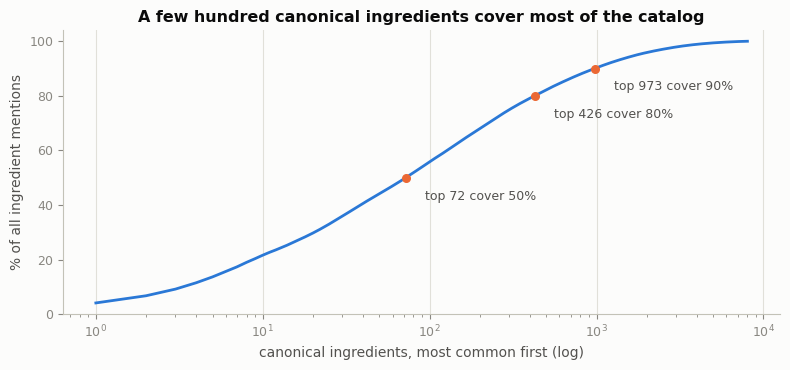

In [17]:
canon = recipes["ingredients_list"].explode().map(dict(zip(ingr_map["raw_ingr"], ingr_map["id"])))
counts = canon.value_counts()
cum = counts.cumsum().to_numpy() / counts.sum()
print(f"{len(canon):,} ingredient mentions | {100 * canon.isna().mean():.1f}% unmapped | "
      f"{len(counts):,} distinct canonical ingredients")

fig, ax = plt.subplots(figsize=(8, 3.8))
style(ax)
ax.plot(np.arange(1, len(cum) + 1), 100 * cum, color=BLUE, linewidth=2)
ax.set_xscale("log")
for q in (0.5, 0.8, 0.9):
    r = int(np.searchsorted(cum, q)) + 1
    ax.scatter([r], [100 * q], color=ORANGE, s=30, zorder=3)
    ax.annotate(f"top {r:,} cover {int(100 * q)}%", (r, 100 * q),
                xytext=(r * 1.3, 100 * q - 8), color=INK2, fontsize=9)
ax.set_title("A few hundred canonical ingredients cover most of the catalog")
ax.set_xlabel("canonical ingredients, most common first (log)")
ax.set_ylabel("% of all ingredient mentions")
ax.set_ylim(0, 104)
fig.tight_layout(); plt.show()

**Feature design:** the top **426** canonical ingredients cover 80% of all mentions (973 cover
90%), so a few-hundred-column indicator matrix is enough for ingredient features, with everything
rarer bucketed as "other". Always join through `ingr_map` ids, never raw strings.

## 8 · Activity over time

Food.com peaked around 2007–2009. Both new recipes and new ratings decline steeply afterwards —
recent years are thin, which matters if we ever slice models by time.

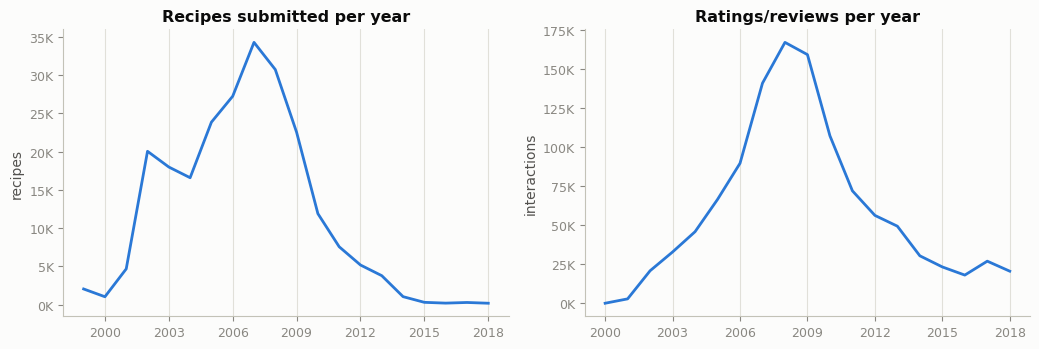

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))

by_year_r = recipes.submitted.dt.year.value_counts().sort_index()
ax = style(axes[0])
ax.plot(by_year_r.index, by_year_r.values, color=BLUE, linewidth=2)
ax.set_title("Recipes submitted per year")
ax.set_ylabel("recipes")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v / 1000:.0f}K"))

by_year_i = interactions.date.dt.year.value_counts().sort_index()
ax = style(axes[1])
ax.plot(by_year_i.index, by_year_i.values, color=BLUE, linewidth=2)
ax.set_title("Ratings/reviews per year")
ax.set_ylabel("interactions")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v / 1000:.0f}K"))

for ax in axes:
    ax.set_xticks(range(2000, 2019, 3))
fig.tight_layout(); plt.show()

## 9 · Ratings — a heavy 5-star skew, plus zeros

Ratings are *not* a bell curve: **72% of all interactions are 5 stars**. There is also a block of
**rating = 0** rows (5.4%) — on Food.com, 0 means the reviewer left a comment *without* awarding
stars, not that they hated the recipe.

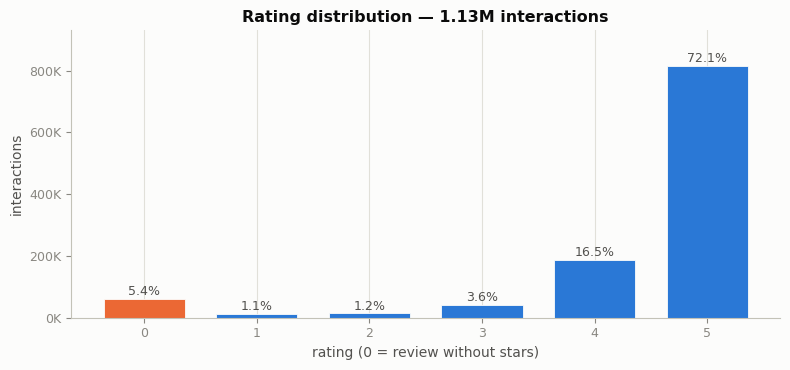

In [19]:
rc = interactions.rating.value_counts().sort_index()
share = 100 * rc / rc.sum()

fig, ax = plt.subplots(figsize=(8, 3.8))
style(ax)
colors = [ORANGE if r == 0 else BLUE for r in rc.index]
bars = ax.bar(rc.index, rc.values, color=colors, edgecolor=SURFACE, linewidth=0.6, width=0.72)
for r, v in rc.items():
    ax.text(r, v + 12_000, f"{share[r]:.1f}%", ha="center", color=INK2, fontsize=9)
ax.set_title("Rating distribution — 1.13M interactions")
ax.set_xlabel("rating (0 = review without stars)"); ax.set_ylabel("interactions")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v / 1000:.0f}K"))
ax.set_ylim(0, rc.max() * 1.14)
fig.tight_layout(); plt.show()

In [20]:
zero = interactions[interactions.rating == 0]
print(f"zero-rated interactions: {len(zero):,} ({100 * len(zero) / len(interactions):.1f}%)")
print(f"avg review length: rating=0 -> {zero.review.str.len().mean():.0f} chars, "
      f"overall -> {interactions.review.str.len().mean():.0f} chars\n")
print("sample zero-rating reviews:")
for txt in zero.review.dropna().head(3):
    print("  •", txt[:180].replace("\n", " "), "…")

zero-rated interactions: 60,847 (5.4%)
avg review length: rating=0 -> 251 chars, overall -> 278 chars

sample zero-rating reviews:
  • Just an observation, so I will not rate.  I followed this procedure with strawberries instead of raspberries.  Perhaps this is the reason it did not work well.  Sorry to report tha …
 This mix is extremely flavorful and its light .  I didnt do the bbq th …nless/boneless chicken fillets.  3 lbs.
  • This is a very good recipe.  We also want to cut back on the fat content in our diet . Very tasty dish!!! …


**Zero-rating policy** (`config.yaml → data.zero_rating_policy`). Zeros are real engagement but not a
star judgment. Treating 0 as "worst possible" would poison the rating scale (it would sit below
"1 = hated it"). Recommended: **exclude zeros from rating-prediction training**, but keep them as a
weak positive *interaction* signal for the Bayesian layer (the user cared enough to cook/comment).

## 10 · Long tail & sparsity

Classic recommender territory: most users rate once, most recipes are rated once or twice, and a tiny
head of popular recipes absorbs a large share of all interactions.

In [21]:
per_user = interactions.groupby("user_id").size().sort_values(ascending=False)
per_recipe = interactions.groupby("recipe_id").size().sort_values(ascending=False)

n_users, n_items = interactions.user_id.nunique(), interactions.recipe_id.nunique()
density = len(interactions) / (n_users * n_items)
print(f"users {n_users:,} × recipes {n_items:,} -> density {100 * density:.4f}% "
      f"(1 observed cell per {1 / density:,.0f})")
print(f"users with a single rating:   {100 * (per_user == 1).mean():.1f}%   (median = {per_user.median():.0f})")
print(f"recipes with ≤ 2 ratings:     {100 * (per_recipe <= 2).mean():.1f}%   (median = {per_recipe.median():.0f})")
top1 = per_recipe.head(int(len(per_recipe) * 0.01)).sum()
print(f"top 1% most-rated recipes hold {100 * top1 / len(interactions):.1f}% of all interactions")

users 226,570 × recipes 231,637 -> density 0.0022% (1 observed cell per 46,347)
users with a single rating:   73.4%   (median = 1)
recipes with ≤ 2 ratings:     59.2%   (median = 2)
top 1% most-rated recipes hold 23.4% of all interactions


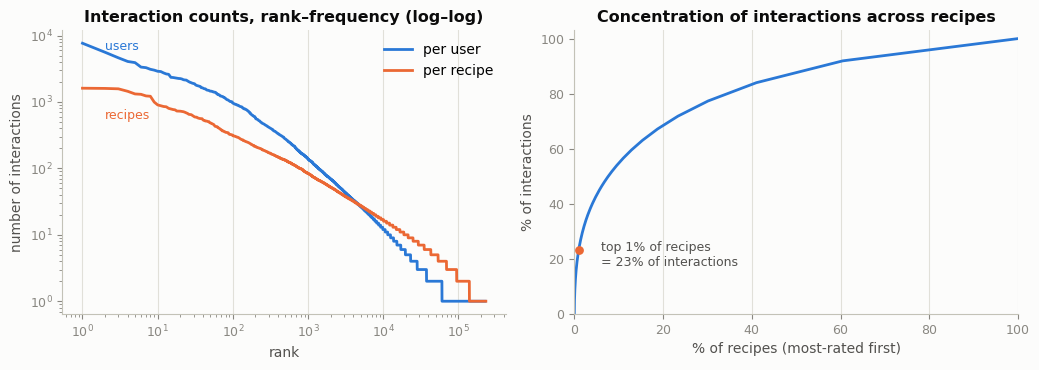

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))

ax = style(axes[0])
ax.plot(np.arange(1, len(per_user) + 1), per_user.values, color=BLUE, linewidth=2, label="per user")
ax.plot(np.arange(1, len(per_recipe) + 1), per_recipe.values, color=ORANGE, linewidth=2, label="per recipe")
ax.set_xscale("log"); ax.set_yscale("log")
ax.text(2, per_user.iloc[1] * 1.1, "users", color=BLUE, fontsize=9)
ax.text(2, per_recipe.iloc[1] * 0.35, "recipes", color=ORANGE, fontsize=9)
ax.legend(loc="upper right")
ax.set_title("Interaction counts, rank–frequency (log–log)")
ax.set_xlabel("rank"); ax.set_ylabel("number of interactions")

ax = style(axes[1])
cum = per_recipe.cumsum() / per_recipe.sum()
frac = np.arange(1, len(cum) + 1) / len(cum)
ax.plot(100 * frac, 100 * cum.values, color=BLUE, linewidth=2)
x1, y1 = 1, 100 * cum.iloc[int(len(cum) * 0.01) - 1]
ax.scatter([x1], [y1], color=ORANGE, zorder=3, s=28)
ax.annotate(f"top 1% of recipes\n= {y1:.0f}% of interactions", (x1, y1),
            xytext=(6, y1 - 6), color=INK2, fontsize=9)
ax.set_title("Concentration of interactions across recipes")
ax.set_xlabel("% of recipes (most-rated first)"); ax.set_ylabel("% of interactions")
ax.set_xlim(0, 100); ax.set_ylim(0, 103)

fig.tight_layout(); plt.show()

**Implications.** At 0.002% density, plain SVD needs strong regularization and bias terms, and
per-user posteriors will be dominated by priors for the ~73% of users with one rating. This is the
core argument for the Bayesian layer: it produces honest *uncertainty* for exactly those users, and
tag-level preferences pool information across recipes instead of relying on per-item factors.

## 11 · Train / validation / test splits

The provided splits come from the dataset's source paper (Majumder et al. 2019), which built them for
**recipe generation**, not rating prediction — and that shows up in the overlap structure.

In [23]:
splits = {"train": train, "validation": validation, "test": test}
summary = pd.DataFrame({
    name: {
        "rows": len(d),
        "users": d.user_id.nunique(),
        "recipes": d.recipe_id.nunique(),
        "zero ratings": int((d.rating == 0).sum()),
        "mean rating (>0)": d.loc[d.rating > 0, "rating"].mean(),
        "first date": d.date.min(),
        "last date": d.date.max(),
    }
    for name, d in splits.items()
}).T
display(summary)

tr_users, tr_items = set(train.user_id), set(train.recipe_id)
for name in ["validation", "test"]:
    d = splits[name]
    print(f"{name:>10}: {100 * d.user_id.isin(tr_users).mean():5.1f}% of users seen in train | "
          f"{100 * d.recipe_id.isin(tr_items).mean():5.1f}% of recipes seen in train | "
          f"max rows per user = {d.user_id.value_counts().max()}")

,rows,users,recipes,zero ratings,mean rating (>0),first date,last date
train,698901,25076,160901,16957,4.69,2000-02-25,2018-12-19
validation,7023,7023,6621,356,4.46,2000-12-06,2018-12-11
test,12455,12455,11695,687,4.46,2000-10-05,2018-12-18


validation: 100.0% of users seen in train |   0.0% of recipes seen in train | max rows per user = 1
      test: 100.0% of users seen in train |   0.0% of recipes seen in train | max rows per user = 1


**Every validation/test user appears in train, but *none* of their recipes do.** The split
partitions *recipes* into disjoint sets (and holds out one interaction per user), so under this split
every evaluation item is **100% item-cold-start**:

- A vanilla SVD's item factors are undefined for every val/test recipe — it can only fall back to
  user + global bias terms. Evaluating SVD on these files as-is mostly measures the bias terms.
- Recipe *features* (tags, ingredients, nutrition, minutes) transfer to unseen recipes — the
  Bayesian feature-preference layer is evaluable on these splits, and this is precisely where it can
  beat collaborative filtering.

**Recommendation:** evaluate the SVD baseline on a *random or per-user-chronological* holdout drawn
from train (warm items), and use the provided validation/test files to evaluate the feature-based
Bayesian layer and the hybrid — reporting both regimes separately.

,train,validation,test
rating,,,
0.000000,2.4%,5.1%,5.5%
1.000000,0.5%,1.9%,2.0%
2.000000,1.0%,2.5%,2.5%
3.000000,3.7%,6.6%,6.5%
4.000000,18.2%,23.3%,22.5%
5.000000,74.2%,60.7%,60.9%


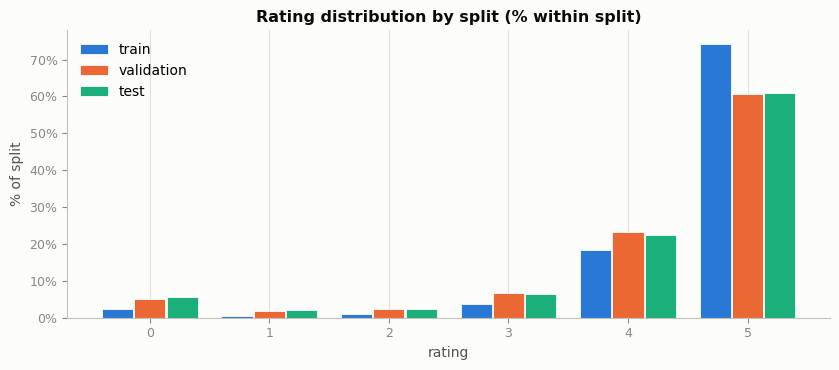

In [24]:
rc_split = pd.DataFrame({
    name: 100 * d.rating.value_counts(normalize=True).sort_index()
    for name, d in splits.items()
}).fillna(0)
display(rc_split.round(1).rename_axis("rating").style.format("{:.1f}%"))

fig, ax = plt.subplots(figsize=(8.5, 3.8))
style(ax)
w, offs = 0.26, [-0.27, 0.0, 0.27]
for (name, col), off in zip([("train", BLUE), ("validation", ORANGE), ("test", AQUA)], offs):
    ax.bar(rc_split.index + off, rc_split[name], width=w, color=col,
           edgecolor=SURFACE, linewidth=0.6, label=name)
ax.set_title("Rating distribution by split (% within split)")
ax.set_xlabel("rating"); ax.set_ylabel("% of split")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc="upper left")
fig.tight_layout(); plt.show()

In [25]:
# The splits ship internal contiguous ids (u, i) for building matrices directly
all_u = pd.concat([train.u, validation.u, test.u])
all_i = pd.concat([train.i, validation.i, test.i])
print(f"u: min {all_u.min()}, max {all_u.max():,}, unique {all_u.nunique():,} -> "
      f"{'contiguous 0..N-1' if all_u.nunique() == all_u.max() + 1 else 'NOT contiguous'}")
print(f"i: min {all_i.min()}, max {all_i.max():,}, unique {all_i.nunique():,} -> "
      f"{'contiguous 0..N-1' if all_i.nunique() == all_i.max() + 1 else 'NOT contiguous'}")
print(f"\nsplit users are a subset of RAW users with ≥ 2 interactions "
      f"(train covers {train.user_id.nunique():,} of {interactions.user_id.nunique():,} RAW users)")

u: min 0, max 25,075, unique 25,076 -> contiguous 0..N-1
i: min 0, max 178,264, unique 178,265 -> contiguous 0..N-1

split users are a subset of RAW users with ≥ 2 interactions (train covers 25,076 of 226,570 RAW users)


## 12 · From stars to "did they enjoy it?"

The Bayesian layer predicts a yes/no outcome: *will this user enjoy this recipe?* So the 1-5 stars
must be turned into a yes/no signal — and because ratings here are extremely positive, the choice of
cutoff matters more than it looks.

Two candidate definitions (0-star rows are excluded, per section 9):

- **"enjoyed" = 4-5 stars** — the natural reading of the scale
- **"loved" = 5 stars only** — stricter, worth considering because 5s dominate everything

In [26]:
# One working table: train interactions + the candidate tags of the rated recipe.
# (tag_flags was built in section 6; dates become datetimes here for the time checks below.)
for df in (train, validation, test):
    df["date"] = pd.to_datetime(df["date"])

rec_feat = pd.concat([recipes[["id", "minutes", "calories"]], tag_flags], axis=1)
for fam, fam_tags in candidates.items():
    rec_feat[f"any_{fam}"] = tag_flags[fam_tags].any(axis=1)

train_feat = train.merge(rec_feat, left_on="recipe_id", right_on="id", how="left")
starred_tr = train_feat[train_feat.rating > 0].copy()
starred_tr["liked"] = starred_tr.rating >= 4   # "enjoyed"
starred_tr["loved"] = starred_tr.rating == 5   # stricter

print(f"train rows with stars: {len(starred_tr):,} of {len(train_feat):,} "
      f"({100 * len(starred_tr) / len(train_feat):.1f}% - the rest are 0-star reviews)")
print(f'  "enjoyed" (4-5 stars): {100 * starred_tr.liked.mean():.1f}% yes')
print(f'  "loved"   (5 stars):   {100 * starred_tr.loved.mean():.1f}% yes')

stars_per_user = starred_tr.groupby("user_id").rating.agg(["count", "min"])
regular = stars_per_user[stars_per_user["count"] >= 3]
print(f"\namong {len(regular):,} users with >=3 starred train ratings:")
print(f"  never rate below 4: {100 * (regular['min'] >= 4).mean():.1f}%")
print(f"  give ONLY 5s:       {100 * (regular['min'] == 5).mean():.1f}%")
active = stars_per_user[stars_per_user["count"] >= 10]
print(f"among {len(active):,} users with >=10 starred ratings, only-5s: "
      f"{100 * (active['min'] == 5).mean():.1f}%")

train rows with stars: 681,944 of 698,901 (97.6% - the rest are 0-star reviews)
  "enjoyed" (4-5 stars): 94.7% yes
  "loved"   (5 stars):   76.0% yes

among 19,940 users with >=3 starred train ratings:
  never rate below 4: 58.1%
  give ONLY 5s:       28.8%
among 9,055 users with >=10 starred ratings, only-5s: 11.2%


**What this means.** Under "enjoyed", 94.7% of answers are yes — always answering yes scores
94.7%, so all personal taste has to show up inside a ~5-point sliver. "Loved" (76% yes) leaves far
more room to tell tastes apart. And roughly **29% of regular raters give nothing but 5s**: their
stars carry no contrast at all. For them the informative signal is *which recipes they chose to cook
and rate* — the same reason the 0-star reviews are worth keeping as weak positives (section 9).

Practical rule for notebook 03: track posteriors under both definitions (they are cheap), and always
compare a user's tag-level rate to *their own* baseline rather than to 100%.

## 13 · Do recipe features move ratings for *everyone*?

Before modeling *personal* taste, check the simpler thing: does any recipe feature shift the like
rate **globally**, for all users pooled together? If "greek" recipes were enjoyed 99% of the time and
"indian" 80%, a model would not need personalization — the tag alone would do the work.

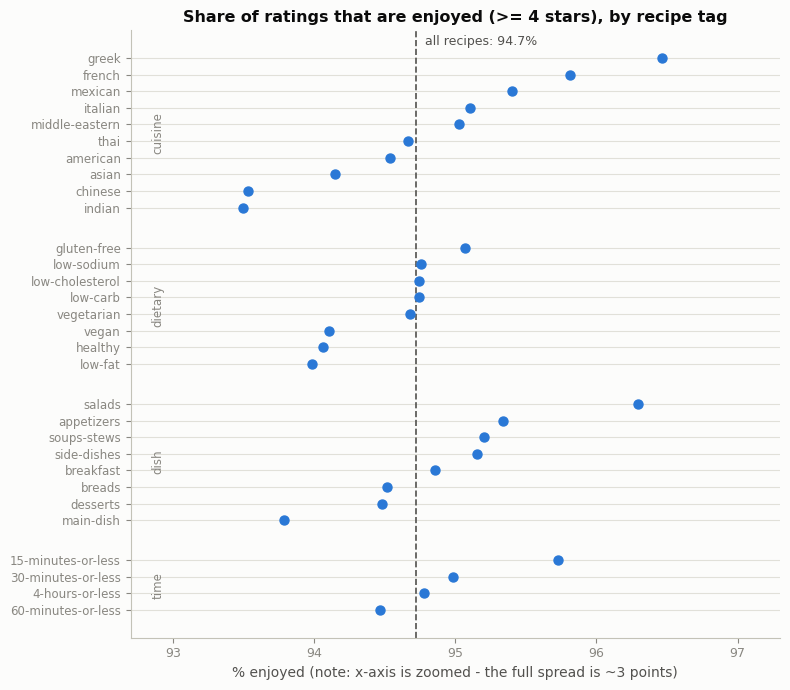

In [27]:
fam_order = list(candidates)
rows = []
for fam in fam_order:
    for t in candidates[fam]:
        rows.append((fam, t, 100 * starred_tr.loc[starred_tr[t], "liked"].mean()))
tag_rate = pd.DataFrame(rows, columns=["family", "tag", "pct_liked"])
overall_pct = 100 * starred_tr.liked.mean()

fig, ax = plt.subplots(figsize=(8, 7))
style(ax, xgrid=True)
ypos, ylab, y = [], [], 0
for fam in reversed(fam_order):
    sub = tag_rate[tag_rate.family == fam].sort_values("pct_liked")
    yy = y + np.arange(len(sub))
    ax.scatter(sub.pct_liked, yy, s=42, color=BLUE, zorder=3)
    ax.text(92.85, y + (len(sub) - 1) / 2, fam, rotation=90, va="center",
            color=MUTED, fontsize=8.5)
    ypos += list(yy); ylab += list(sub.tag)
    y += len(sub) + 1.4
ax.axvline(overall_pct, color=INK2, linewidth=1.2, linestyle="--")
ax.text(overall_pct + 0.06, y - 1.6, f"all recipes: {overall_pct:.1f}%", color=INK2, fontsize=9)
ax.set_yticks(ypos, ylab, fontsize=8.5)
ax.set_xlim(92.7, 97.3)
ax.set_title("Share of ratings that are enjoyed (>= 4 stars), by recipe tag")
ax.set_xlabel("% enjoyed (note: x-axis is zoomed - the full spread is ~3 points)")
fig.tight_layout(); plt.show()

In [28]:
mins = starred_tr.minutes.where(starred_tr.minutes.between(1, 1440))
by_min = starred_tr.groupby(pd.cut(mins, [0, 15, 30, 60, 120, 1440]), observed=True).liked.mean()
cal99 = starred_tr.calories.quantile(0.99)
by_cal = starred_tr.groupby(pd.cut(starred_tr.calories.clip(upper=cal99),
                                   [0, 200, 400, 600, 1000, cal99]), observed=True).liked.mean()
print("% enjoyed by cooking time (min):")
print((100 * by_min).round(1).to_string())
print("\n% enjoyed by calories per serving:")
print((100 * by_cal).round(1).to_string())

% enjoyed by cooking time (min):
minutes
(0, 15]       95.80
(15, 30]      95.00
(30, 60]      94.50
(60, 120]     94.80
(120, 1440]   93.10

% enjoyed by calories per serving:
calories
(0.0, 200.0]       94.90
(200.0, 400.0]     94.80
(400.0, 600.0]     94.50
(600.0, 1000.0]    94.50
(1000.0, 2870.8]   94.90


**Nearly flat.** Every cuisine sits between 93.5% and 96.5%; dietary tags span barely one
point; calories make no visible difference at all; only very long cooking times dip slightly (95.8%
for quick recipes vs 93.1% beyond two hours). No feature moves the needle for everyone at once.

That is not bad news — it sharpens the design: **if recipe features help, it can only be because
different users react differently to the same feature.** Which is exactly the next question.

## 14 · Do users actually differ in taste? (the premise of the Bayesian layer)

Two different things could hide inside "users differ":

1. **Generosity** — some users hand out 5s to everything; others use the whole scale.
2. **Taste** — a user enjoys, say, *dessert* recipes more (or less) than their *other* recipes.

Both are checked against the same benchmark: **luck alone**. Even if every user shared identical
taste, their observed like rates would still spread out, because each user is only a handful of coin
flips. We can compute how much spread luck by itself produces, then ask: is the real spread wider?

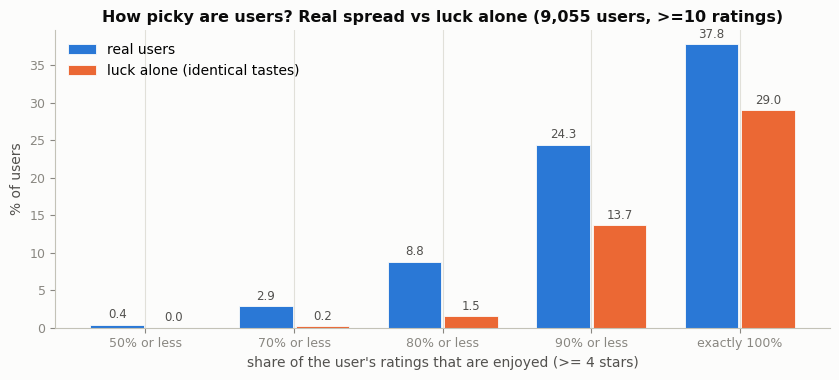

spread of per-user like rates: real 9.0 pts vs luck alone 4.8 pts


In [29]:
by_user = starred_tr.groupby("user_id").liked.agg(["sum", "count"])
by_user = by_user[by_user["count"] >= 10]              # users with enough flips to judge
rate_real = by_user["sum"] / by_user["count"]

# The luck-alone world: everyone shares one true rate; only sample size varies
pooled = by_user["sum"].sum() / by_user["count"].sum()
rng = np.random.default_rng(CFG["data"]["random_seed"])
rate_luck = rng.binomial(by_user["count"].values, pooled) / by_user["count"].values

levels = [("50% or less", lambda r: r <= 0.5), ("70% or less", lambda r: r <= 0.7),
          ("80% or less", lambda r: r <= 0.8), ("90% or less", lambda r: r <= 0.9),
          ("exactly 100%", lambda r: r == 1.0)]
share_real = [100 * f(rate_real).mean() for _, f in levels]
share_luck = [100 * f(rate_luck).mean() for _, f in levels]

fig, ax = plt.subplots(figsize=(8.5, 3.9))
style(ax)
x = np.arange(len(levels))
ax.bar(x - 0.19, share_real, width=0.36, color=BLUE, edgecolor=SURFACE,
       linewidth=0.6, label="real users")
ax.bar(x + 0.19, share_luck, width=0.36, color=ORANGE, edgecolor=SURFACE,
       linewidth=0.6, label="luck alone (identical tastes)")
for xi, (r, l) in enumerate(zip(share_real, share_luck)):
    ax.text(xi - 0.19, r + 0.9, f"{r:.1f}", ha="center", color=INK2, fontsize=8.5)
    ax.text(xi + 0.19, l + 0.9, f"{l:.1f}", ha="center", color=INK2, fontsize=8.5)
ax.set_xticks(x, [name for name, _ in levels])
ax.set_title(f"How picky are users? Real spread vs luck alone ({len(by_user):,} users, >=10 ratings)")
ax.set_xlabel("share of the user's ratings that are enjoyed (>= 4 stars)")
ax.set_ylabel("% of users")
ax.legend(loc="upper left")
fig.tight_layout(); plt.show()

print(f"spread of per-user like rates: real {100 * rate_real.std():.1f} pts "
      f"vs luck alone {100 * rate_luck.std():.1f} pts")

In [30]:
def taste_spread(tag, like_col="liked", min_n=8):
    """Per-user lift = like rate ON the tag minus like rate OFF it, then compare the spread
    of lifts across users with the spread luck alone would produce."""
    on = starred_tr[starred_tr[tag]].groupby("user_id")[like_col].agg(k_on="sum", n_on="count")
    off = starred_tr[~starred_tr[tag]].groupby("user_id")[like_col].agg(k_off="sum", n_off="count")
    j = on.join(off, how="inner")
    j = j[(j.n_on >= min_n) & (j.n_off >= min_n)]
    if len(j) < 100:                     # not enough users to measure the spread
        return None
    lift = j.k_on / j.n_on - j.k_off / j.n_off
    base = (j.k_on + j.k_off) / (j.n_on + j.n_off)
    luck_var = (base * (1 - base) * (1 / j.n_on + 1 / j.n_off)).mean()
    return {"tag": tag, "users": len(j), "real_spread_pp": 100 * lift.std(ddof=1),
            "luck_spread_pp": 100 * np.sqrt(luck_var),
            "spread_ratio": lift.var(ddof=1) / luck_var}

taste = pd.DataFrame([r for t in CAND_TAGS if (r := taste_spread(t)) is not None])
taste = taste.sort_values("spread_ratio", ascending=False).reset_index(drop=True)
print(f"median spread ratio across {len(taste)} tags: {taste.spread_ratio.median():.2f} "
      "(1.00 = no taste differences beyond luck)")
display(taste.round(2).style.format({"real_spread_pp": "{:.1f}", "luck_spread_pp": "{:.1f}",
                                     "spread_ratio": "{:.2f}"}).hide(axis="index"))

print('same test with the stricter "loved" (5-star) definition:')
for t in ["desserts", "main-dish", "italian"]:
    r = taste_spread(t, "loved")
    print(f"  {t:12s}: real {r['real_spread_pp']:.1f} vs luck {r['luck_spread_pp']:.1f} pts "
          f"(ratio {r['spread_ratio']:.2f})")

median spread ratio across 29 tags: 1.08 (1.00 = no taste differences beyond luck)


tag,users,real_spread_pp,luck_spread_pp,spread_ratio
middle-eastern,108,8.5,5.1,2.77
italian,632,7.1,6.3,1.26
low-fat,1465,7.4,6.7,1.23
chinese,144,6.3,5.7,1.21
low-sodium,2351,7.3,6.7,1.17
desserts,2676,7.5,7.0,1.16
main-dish,4502,7.9,7.4,1.15
soups-stews,759,6.8,6.3,1.15
asian,895,7.0,6.6,1.12
healthy,2516,7.3,6.9,1.11


same test with the stricter "loved" (5-star) definition:
  desserts    : real 12.6 vs luck 11.7 pts (ratio 1.17)
  main-dish   : real 13.3 vs luck 12.3 pts (ratio 1.17)
  italian     : real 12.0 vs luck 11.5 pts (ratio 1.07)


**Verdict: yes on generosity, modestly on taste.**

- **Generosity is the big personal effect.** Real per-user like rates spread ~9 points against ~5
  from luck alone (3.5x the variance). 8.8% of users enjoy 80% or fewer of their recipes — luck
  alone would produce 1.5%.
- **Tag-level taste is real but small.** After subtracting each user's own baseline, the spread of
  tag lifts is typically only ~5-25% wider than luck (median ratio ≈ 1.08). That works out to honest
  taste differences of roughly ±3 points under "enjoyed", ±5 under "loved" — the stricter
  definition separates tastes a little better.

Consequences for notebook 03: model **each user's baseline rate first** (that is where the personal
signal lives), treat tag preferences as **small adjustments around that baseline** with informative
priors, and expect posteriors that say "close to this user's usual rate, slightly higher for
desserts" — not dramatic swings. It also means honest **uncertainty intervals will be wide** for
most users, which is precisely what this project promises to report.

## 15 · How much evidence does the updater get per user?

A posterior only moves away from its prior when data arrives. Train users have a median of just
**6 interactions** — but each rated recipe carries several candidate tags (median 3), so tag-level
evidence accumulates faster than the raw count suggests. The question: for how many users does each
feature actually get enough observations to matter?

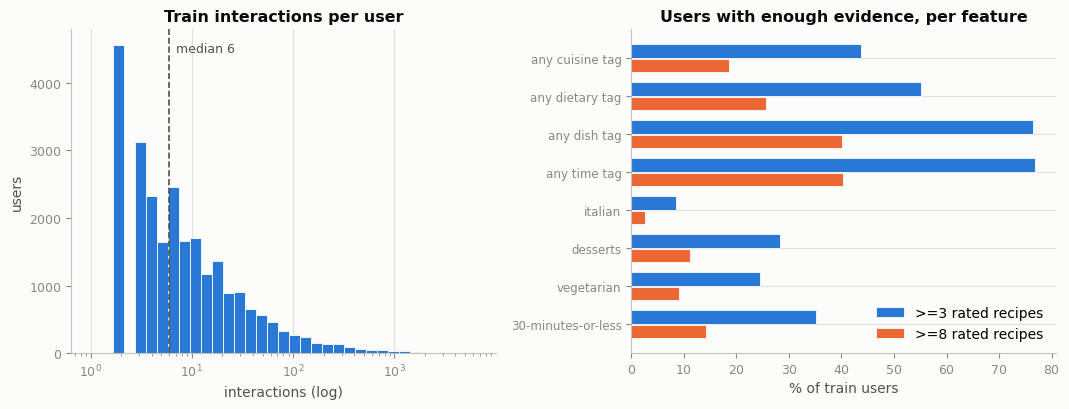

In [31]:
n_per_user = train.groupby("user_id").size()
exposure = [(f"any {fam} tag", starred_tr.groupby("user_id")[f"any_{fam}"].sum())
            for fam in candidates]
exposure += [(t, starred_tr.groupby("user_id")[t].sum())
             for t in ["italian", "desserts", "vegetarian", "30-minutes-or-less"]]

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2))
ax = style(axes[0])
ax.hist(n_per_user, bins=np.logspace(0, np.log10(n_per_user.max()), 36),
        color=BLUE, edgecolor=SURFACE, linewidth=0.6)
ax.set_xscale("log")
med = n_per_user.median()
ax.axvline(med, color=INK2, linewidth=1.2, linestyle="--")
ax.text(med * 1.15, ax.get_ylim()[1] * 0.93, f"median {med:.0f}", color=INK2, fontsize=9)
ax.set_title("Train interactions per user")
ax.set_xlabel("interactions (log)"); ax.set_ylabel("users")

ax = style(axes[1], xgrid=True)
labels = [name for name, _ in exposure]
ge3 = [100 * (c >= 3).mean() for _, c in exposure]
ge8 = [100 * (c >= 8).mean() for _, c in exposure]
y = np.arange(len(labels))[::-1]
ax.barh(y + 0.19, ge3, height=0.36, color=BLUE, edgecolor=SURFACE, linewidth=0.6,
        label=">=3 rated recipes")
ax.barh(y - 0.19, ge8, height=0.36, color=ORANGE, edgecolor=SURFACE, linewidth=0.6,
        label=">=8 rated recipes")
ax.set_yticks(y, labels, fontsize=8.5)
ax.set_title("Users with enough evidence, per feature")
ax.set_xlabel("% of train users")
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

**Families work; single cuisines mostly do not.** Around 77% of users have at least 3 rated
recipes touching *dish-type* or *cooking-time* tags, so those posteriors genuinely learn. But a
specific cuisine like *italian* reaches 3 observations for only **8% of users** (the median user has
zero). For most users, most cuisine posteriors will simply sit at the prior. Two design responses:
build the layer at the **family level first** (or pool tags hierarchically), and report uncertainty —
for thin-evidence features it is the honest part of the answer.

## 16 · Time — is the held-out rating really "the future"?

The project's pitch is *sequential*: learn from a user's past ratings, then predict the next one.
That story silently assumes the held-out interaction comes **after** the ratings we update on. The
provided split holds out exactly one interaction per user — check where it falls in each user's
timeline.

In [32]:
last_train = train.groupby("user_id").date.max()
first_train = train.groupby("user_id").date.min()
for name, d in [("validation", validation), ("test", test)]:
    after = (d.date > d.user_id.map(last_train)).mean()
    before = (d.date < d.user_id.map(first_train)).mean()
    print(f"{name}: after ALL of the user's train ratings {100 * after:.1f}% | "
          f"in the middle {100 * (1 - after - before):.1f}% | "
          f"before the user's FIRST {100 * before:.1f}%")

validation: after ALL of the user's train ratings 9.1% | in the middle 82.8% | before the user's FIRST 8.1%
test: after ALL of the user's train ratings 12.8% | in the middle 75.4% | before the user's FIRST 11.7%


**It usually is not the future.** Only ~9% (validation) / ~13% (test) of held-out ratings
come after everything the user has in train — about **83% / 76% sit in the middle of the user's
history**, and roughly one in ten even predates the user's first train rating. The split was built
recipe-disjoint (section 11), not chronological.

Scoring predictions on these files is fine. But a claim like "the system updated on the user's past
and predicted their next rating" needs a different protocol: **replay each user's train history in
date order** (predict → observe → update, one rating at a time), or carve a last-interaction-per-user
holdout out of train. Otherwise the update step quietly uses the future to predict the past.

In [33]:
srt = train.sort_values(["user_id", "date"])
gap_days = srt.groupby("user_id").date.diff().dt.days.dropna()
gm = train.groupby("user_id").date.agg(["min", "max", "count"])
span_days = (gm["max"] - gm["min"]).dt.days[gm["count"] >= 2]
print(f"gap between consecutive ratings: same-day {100 * (gap_days == 0).mean():.0f}% | "
      f"median {gap_days.median():.0f} d | P90 {gap_days.quantile(0.9):.0f} d")
print(f"per-user history span: median {span_days.median():,.0f} days "
      f"(~{span_days.median() / 365:.1f} years); {100 * (span_days > 30).mean():.0f}% span > 1 month\n")

# Are tastes stable enough to accumulate? Split each heavy user's history in half by date.
n_starred = starred_tr.groupby("user_id").size()
heavy = n_starred[n_starred >= 20].index
h = starred_tr[starred_tr.user_id.isin(heavy)].sort_values(["user_id", "date"]).copy()
h["second_half"] = h.groupby("user_id").cumcount() >= h.groupby("user_id")["rating"].transform("size") // 2
profile = h.groupby(["user_id", "second_half"])[CAND_TAGS].sum()
first = profile.xs(False, level="second_half").sort_index().to_numpy(float)
second = profile.xs(True, level="second_half").sort_index().to_numpy(float)

def row_cosine(a, b):
    den = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)
    return np.where(den > 0, (a * b).sum(1) / np.where(den > 0, den, 1), np.nan)

own = row_cosine(first, second)
stranger = row_cosine(first, np.roll(second, 1, axis=0))    # paired with a different user
half_rate = h.groupby(["user_id", "second_half"]).liked.mean().unstack()
print(f"{len(heavy):,} heavy users (>=20 starred ratings), earlier half vs later half:")
print(f"  tag profile vs the user's OWN later half:       cosine {np.nanmedian(own):.2f} (median)")
print(f"  tag profile vs the later half of ANOTHER user:  cosine {np.nanmedian(stranger):.2f}")
print(f"  like-rate stability: corr {half_rate[False].corr(half_rate[True]):.2f}, "
      f"mean shift {100 * (half_rate[True] - half_rate[False]).abs().mean():.1f} pts")

gap between consecutive ratings: same-day 30% | median 3 d | P90 89 d
per-user history span: median 829 days (~2.3 years); 91% span > 1 month

5,130 heavy users (>=20 starred ratings), earlier half vs later half:
  tag profile vs the user's OWN later half:       cosine 0.87 (median)
  tag profile vs the later half of ANOTHER user:  cosine 0.79
  like-rate stability: corr 0.58, mean shift 5.2 pts


**Histories are long and tastes are steady.** A typical multi-rating user's history spans
**~2.3 years**, and although 30% of consecutive ratings land on the same day (batch raters), real
time passes between sessions — sequential updating describes something real. Stability is good news
for a simple updater: a user's earlier tag profile matches their *own* later profile (cosine 0.87)
better than another user's (0.79), and like rates barely drift (corr 0.58, mean shift ~5 points).
**Plain cumulative updating is a sound v1**; recency-weighting (discounting old evidence) is an
optional refinement, not a requirement.

## 17 · Recipe averages cannot be taken at face value

The same small-sample problem appears on the recipe side. Sorting recipes by average rating sounds
reasonable — until you look at how few ratings most averages rest on.

recipes with starred ratings: 226,590
  single rating: 40% - and 65% of those are one 5-star vote
  'perfect' 5.0 average: 48.6% of the catalog
  among 1,979 recipes with >=50 ratings: 0.35% are perfect


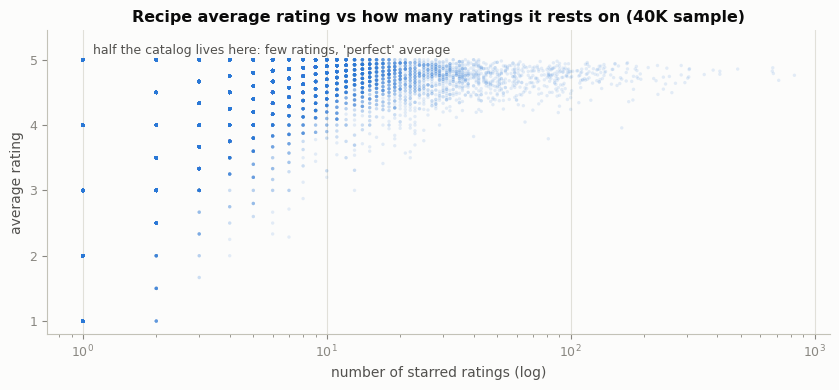

In [34]:
per_recipe_stars = interactions[interactions.rating > 0].groupby("recipe_id").rating.agg(["count", "mean"])
one = per_recipe_stars["count"] == 1
big = per_recipe_stars[per_recipe_stars["count"] >= 50]
print(f"recipes with starred ratings: {len(per_recipe_stars):,}")
print(f"  single rating: {100 * one.mean():.0f}% - and {100 * (per_recipe_stars.loc[one, 'mean'] == 5).mean():.0f}% "
      "of those are one 5-star vote")
print(f"  'perfect' 5.0 average: {100 * (per_recipe_stars['mean'] == 5).mean():.1f}% of the catalog")
print(f"  among {len(big):,} recipes with >=50 ratings: {100 * (big['mean'] == 5).mean():.2f}% are perfect")

samp = per_recipe_stars.sample(40_000, random_state=CFG["data"]["random_seed"])
fig, ax = plt.subplots(figsize=(8.5, 4))
style(ax)
ax.scatter(samp["count"], samp["mean"], s=6, alpha=0.12, color=BLUE, edgecolor="none")
ax.set_xscale("log")
ax.set_title("Recipe average rating vs how many ratings it rests on (40K sample)")
ax.set_xlabel("number of starred ratings (log)"); ax.set_ylabel("average rating")
ax.text(1.1, 5.09, "half the catalog lives here: few ratings, 'perfect' average",
        color=INK2, fontsize=9)
ax.set_ylim(0.8, 5.45)
fig.tight_layout(); plt.show()

**Shrinkage — the same medicine.** A single 5-star vote should not outrank 4.8 over 300
ratings. The Bayesian fix is the one this project is already built on: give every recipe a prior
centered near the global average and let its own ratings pull the posterior away as evidence
accumulates. Small-sample recipes get pulled toward "average" with wide uncertainty; well-rated
recipes keep their mean and earn tight intervals. That hands the hybrid an item-side quality score
*with* a confidence attached — the same Beta-Binomial math as the user layer, so the report tells
one coherent story.

## 18 · Key takeaways for modeling

| # | Finding | Decision it drives |
|---|---------|--------------------|
| 1 | Ratings are 72% five-star; mean ≈ 4.4 | Rating *prediction* has little headroom — report RMSE/MAE against strong mean baselines; consider ranking metrics (NDCG@K) as primary |
| 2 | 5.4% of interactions have rating = 0 (comment without stars) | Exclude from rating training; optionally keep as weak positive signal for Bayesian updating (`data.zero_rating_policy`) |
| 3 | `minutes` has joke outliers up to 2³¹−1; 1K zeros | Cap at 1,440 min (`data.max_minutes_after_cleaning`), treat 0 as missing |
| 4 | Nutrition columns have similar extreme tails | Winsorize at P99 before use as features |
| 5 | 73% of users have exactly one rating; density 0.002% | Cold-start is the norm → Bayesian priors + uncertainty reporting are the point of this project, not an add-on |
| 6 | Top 1% of recipes hold 23% of interactions | Popularity is a strong confounder — include a popularity baseline; consider popularity-debiased ranking |
| 7 | **Provided val/test recipes never appear in train** (recipe-disjoint split) | Evaluate SVD on a warm-item holdout carved from train; use provided splits to evaluate the feature-based Bayesian layer / hybrid |
| 8 | Tags are rich (median 17/recipe) with strong cuisine/dietary/dish coverage | Use tag families as the Beta–Binomial feature space for per-user preference posteriors |
| 9 | Splits ship contiguous `u`/`i` ids | Build sparse matrices directly on `u`/`i`; keep `user_id`/`recipe_id` only for joining metadata |
| 10 | Global like rates are nearly flat across features (cuisines 93.5–96.5%; calories flat) | Features can only help through *per-user* differences — do not expect global tag effects to lift accuracy |
| 11 | "Enjoyed" (≥4★) is 94.7% yes; ~29% of regular raters give only 5s | Also track the stricter "loved" (=5★, 76% yes); a user's stars must be read against *their own* baseline |
| 12 | Generosity varies 3.5× more than luck allows; tag-specific taste is real but small (spread ratio ≈ 1.1) | Model the per-user baseline first; tag preferences are small adjustments with informative priors; expect wide, honest uncertainty |
| 13 | Median train user: 6 interactions; median *italian* exposures: 0 (dish/time families: 5) | Learn preferences at the tag-family level first, or pool hierarchically — single-cuisine posteriors stay at the prior for most users |
| 14 | Only 9% (val) / 13% (test) of held-out ratings fall after the user's train history | For the sequential-updating story, replay each user's train history in date order (predict → update); the provided split alone cannot test it |
| 15 | Tastes are stable (own-history cosine 0.87 vs 0.79 stranger; like-rate corr 0.58) over ~2.3-year histories | Plain cumulative updating is a sound v1; recency weighting is optional |
| 16 | 48.6% of recipes have a perfect 5.0 average (40% have a single rating) | Shrink recipe quality with a Beta prior — same math as the user layer; gives item-side confidence |
| 17 | Dietary tags cluster (Jaccard 0.32–0.59); top 426 canonical ingredients cover 80% of mentions | Collapse the health cluster into one feature; compact ingredient features via `ingr_map` are feasible |

**Hand-off:** cleaning rules → `src/data/cleaning.py`, tag features → `src/features/recipe_features.py`,
split strategy & warm-item holdout -> `notebooks/final/02_svd_baseline.ipynb`, "enjoyed" definition, priors,
and the sequential replay protocol -> `notebooks/final/03_bayesian_updating.ipynb`.